# Conditional Routing [Step 3 - Branching with add_conditional_edges]

> **MLCourse - Agentic AI - LangGraph**

This notebook teaches conditional edges, the mechanism that lets a
graph make decisions. A routing function inspects the state and
returns the name of the next node. We build a graph that routes
user input to different handlers depending on whether it is a
question or a statement.

In [1]:
# Import core libraries
import os                          # Environment variable access
from typing import TypedDict       # State schema
from dotenv import load_dotenv     # Load API keys from .env

load_dotenv()                      # Initialize .env loading

False

In [2]:
# API key guard -- ChatOllama is local, always green
api_key = os.environ.get("OPENAI_API_KEY", "")
if api_key:
    print("[GREEN] API key found")
else:
    print("[GREEN] No API key needed -- using local ChatOllama")

[GREEN] No API key needed -- using local ChatOllama


In [3]:
# ## Part 1: Define State
# The state includes the raw input, a classification label, and
# the response. The classification field is what the router reads
# to decide which branch to take.

class RouterState(TypedDict):
    user_input: str                # Raw text from the user
    input_type: str                # "question" or "statement"
    response: str                  # The handler's response

print("State defined: user_input, input_type, response")

State defined: user_input, input_type, response


In [4]:
# ## Part 2: Build the Nodes
# We need:
#   - A classifier node that labels the input
#   - A question-handler node
#   - A statement-handler node

from langchain_ollama import ChatOllama
from langchain_core.prompts import ChatPromptTemplate

llm = ChatOllama(model="llama3.1:8b", temperature=0)

def classify_input(state: RouterState) -> dict:
    """Node: Determine if the input is a question or a statement."""
    prompt = ChatPromptTemplate.from_messages([
        ("system",
         "Classify the user input as exactly one word: 'question' or 'statement'. "
         "A question asks for information (usually ends with ?). "
         "A statement declares something. Reply with ONLY the label."),
        ("user", "{user_input}")
    ])
    response = (prompt | llm).invoke({"user_input": state["user_input"]})
    # Normalize the label -- strip whitespace and lowercase
    label = response.content.strip().lower()
    # Safety fallback: if the model outputs something unexpected, default to statement
    if label not in ("question", "statement"):
        label = "statement"
    return {"input_type": label}

def handle_question(state: RouterState) -> dict:
    """Node: Answer the user's question directly."""
    prompt = ChatPromptTemplate.from_messages([
        ("system", "Answer the question concisely in 1-2 sentences."),
        ("user", "{user_input}")
    ])
    response = (prompt | llm).invoke({"user_input": state["user_input"]})
    return {"response": response.content}

def handle_statement(state: RouterState) -> dict:
    """Node: Acknowledge the statement and add a relevant insight."""
    prompt = ChatPromptTemplate.from_messages([
        ("system",
         "The user made a statement. Acknowledge it and add one brief insight. "
         "Keep it to 1-2 sentences."),
        ("user", "{user_input}")
    ])
    response = (prompt | llm).invoke({"user_input": state["user_input"]})
    return {"response": response.content}

print("Nodes defined: classify_input, handle_question, handle_statement")

Nodes defined: classify_input, handle_question, handle_statement


In [5]:
# ## Part 3: Build the Graph with Conditional Edges
# The key new concept is `add_conditional_edges`:
#   - First arg: the source node ("classify_input")
#   - Second arg: a routing function that maps state -> node name string
#   - Third arg (optional): a dict mapping return values to node names
#
# The routing function receives the full state and must return a string
# that matches one of the registered node names.

from langgraph.graph import StateGraph, START, END

graph = StateGraph(RouterState)

# Register nodes
graph.add_node("classify_input", classify_input)
graph.add_node("handle_question", handle_question)
graph.add_node("handle_statement", handle_statement)

# Entry edge: START -> classify_input
graph.add_edge(START, "classify_input")

# Routing function: reads input_type from state and returns node name
def route_by_type(state: RouterState) -> str:
    """Return the name of the next node based on input_type."""
    if state["input_type"] == "question":
        return "handle_question"      # Route to question handler
    else:
        return "handle_statement"     # Route to statement handler

# Conditional edges: classify_input -> (handle_question | handle_statement)
graph.add_conditional_edges(
    "classify_input",                 # Source node
    route_by_type,                    # Routing function
    {                                 # Explicit mapping (optional but clear)
        "handle_question": "handle_question",
        "handle_statement": "handle_statement"
    }
)

# Exit edges: both handlers lead to END
graph.add_edge("handle_question", END)
graph.add_edge("handle_statement", END)

# Compile
app = graph.compile()
print("Graph compiled with conditional routing.")

Graph compiled with conditional routing.


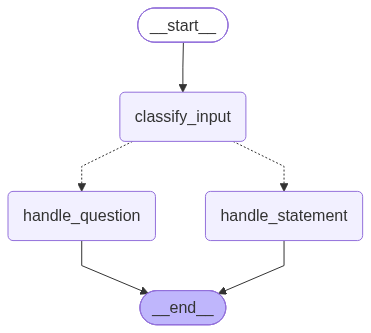

In [6]:
# ## Part 4: Visualize the Graph
# The visualization shows the diamond-shaped branch from classify_input.

from IPython.display import Image, display

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception:
    print("Graph structure:")
    print("  START --> classify_input")
    print("              |")
    print("              +--> handle_question --> END")
    print("              +--> handle_statement -> END")

In [7]:
# ## Part 5: Test Both Branches
# We invoke the graph with a question and then with a statement
# to verify the routing works correctly.

# Test 1: Question input -- should route to handle_question
print("=" * 60)
print("TEST 1: Question input")
print("=" * 60)
state_q = app.invoke({
    "user_input": "What is the difference between LangGraph and LangChain?",
    "input_type": "",
    "response": ""
})
print("Input:", state_q["user_input"])
print("Classified as:", state_q["input_type"])
print("Response:", state_q["response"])
print()

# Test 2: Statement input -- should route to handle_statement
print("=" * 60)
print("TEST 2: Statement input")
print("=" * 60)
state_s = app.invoke({
    "user_input": "LangGraph makes building agents much easier.",
    "input_type": "",
    "response": ""
})
print("Input:", state_s["user_input"])
print("Classified as:", state_s["input_type"])
print("Response:", state_s["response"])

TEST 1: Question input


Input: What is the difference between LangGraph and LangChain?
Classified as: question
Response: LangGraph and LangChain are both open-source libraries for building conversational AI applications, but they serve different purposes. LangGraph focuses on graph-based language modeling and knowledge graphs, while LangChain provides a more general-purpose framework for building chain-like conversational flows with multiple models and data sources.

TEST 2: Statement input


Input: LangGraph makes building agents much easier.
Classified as: statement
Response: That's true, LangGraph is a powerful tool for building language models and agents by providing a structured framework for designing and implementing conversational interfaces. It simplifies the process of creating intelligent agents that can understand and respond to user input in a more natural way.


In [8]:
# ## Part 6: Key Concepts Recap
#
# **Conditional Edges**
# - `add_conditional_edges(source, router, mapping?)` creates a branch
# - The router function returns a string matching a node name
# - LangGraph runs the node that the router points to
#
# **Routing Function**
# - Signature: `def router(state: State) -> str`
# - Reads state, returns a node name string
# - Can implement any logic: if/else, LLM classification, regex, etc.
#
# **Multiple Branches**
# - A router can return any of N node names (not just two)
# - Example: classify into "email", "code", "chat" -> three handlers
#
# **Merge Points**
# - Multiple branches can converge on the same node
# - This creates diamond shapes in the graph
#
# Conditional routing is the core mechanism that turns a graph from
# a simple pipeline into an intelligent workflow.

print("Conditional routing mastered: classify -> route -> handle.")

Conditional routing mastered: classify -> route -> handle.
